# Kaggle model comparison — GRU-AE / VAE / FSMN-AE / TET

Fair **reconstruction-head** comparison on the Kaggle telemetry experiment:

- same processed pool (`Data/kaggle_processed`)
- same 12 features, window=20, stride=1
- labels from dataset failures (`is_anomaly` / `failure_type`) — not synthetic CAN attacks
- each model uses its own saved scaler + calibrated threshold

Outputs land in `kaggle_v1/figures/` (isolated from CARLA `Python scripts/figures/`).

```bash
# CLI equivalent (from kaggle_v1/):
python compare_models.py ../../Data/kaggle_processed
```

Train missing checkpoints first if needed:

```bash
python train_gru.py ../../Data/kaggle_processed --epochs 20
python train_vae.py ../../Data/kaggle_processed --epochs 50
python train_fsmn.py ../../Data/kaggle_processed --epochs 50
python train_tet.py ../../Data/kaggle_processed --epochs 50
```


In [1]:
from pathlib import Path
import subprocess
import sys

cwd = Path.cwd()
if (cwd / "compare_models.py").exists():
    ROOT = cwd
elif (cwd / "kaggle_v1" / "compare_models.py").exists():
    ROOT = cwd / "kaggle_v1"
elif (cwd / "Python scripts" / "kaggle_v1" / "compare_models.py").exists():
    ROOT = cwd / "Python scripts" / "kaggle_v1"
else:
    ROOT = Path("Python scripts/kaggle_v1").resolve()

DATA = ROOT.parents[1] / "Data" / "kaggle_processed"
OUT = ROOT / "figures"
print("ROOT", ROOT)
print("DATA", DATA, "exists=", DATA.exists())
print("OUT ", OUT)


ROOT /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Python scripts/kaggle_v1
DATA /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Data/kaggle_processed exists= True
OUT  /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Python scripts/kaggle_v1/figures


In [2]:
cmd = [
    sys.executable,
    str(ROOT / "compare_models.py"),
    str(DATA),
    "--max-windows", "10000",
    "--latency-n", "400",
    "--outdir", str(OUT),
]
print(" ".join(cmd))
subprocess.run(cmd, check=True, cwd=str(ROOT))


/Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/bin/python3.14 /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Python scripts/kaggle_v1/compare_models.py /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Data/kaggle_processed --max-windows 10000 --latency-n 400 --outdir /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Python scripts/kaggle_v1/figures
[Config] features=12 window=20 stride=1 max_windows=10000

CompletedProcess(args=['/Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/bin/python3.14', '/Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Python scripts/kaggle_v1/compare_models.py', '/Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Data/kaggle_processed', '--max-windows', '10000', '--latency-n', '400', '--outdir', '/Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Python scripts/kaggle_v1/figures'], return

,model,PR AUC,AUROC,macro F1,MCC,recall,FPR,params,size_kib,latency_p50_us,latency_p99_us,prevalence,n_windows,n_pos
0,GRU-AE,0.821,0.957,0.871,0.743,0.720,0.012,9036,35.297,59.188,74.589,0.063,10000,632
1,VAE,0.826,0.959,0.890,0.799,0.655,0.000,40992,160.125,117.959,135.804,0.063,10000,632
2,FSMN-AE,0.908,0.975,0.908,0.816,0.831,0.012,7596,29.672,70.020,141.838,0.063,10000,632
3,TET,0.900,0.981,0.908,0.816,0.804,0.010,68536,267.719,169.021,251.282,0.063,10000,632


feature_heatmap.png


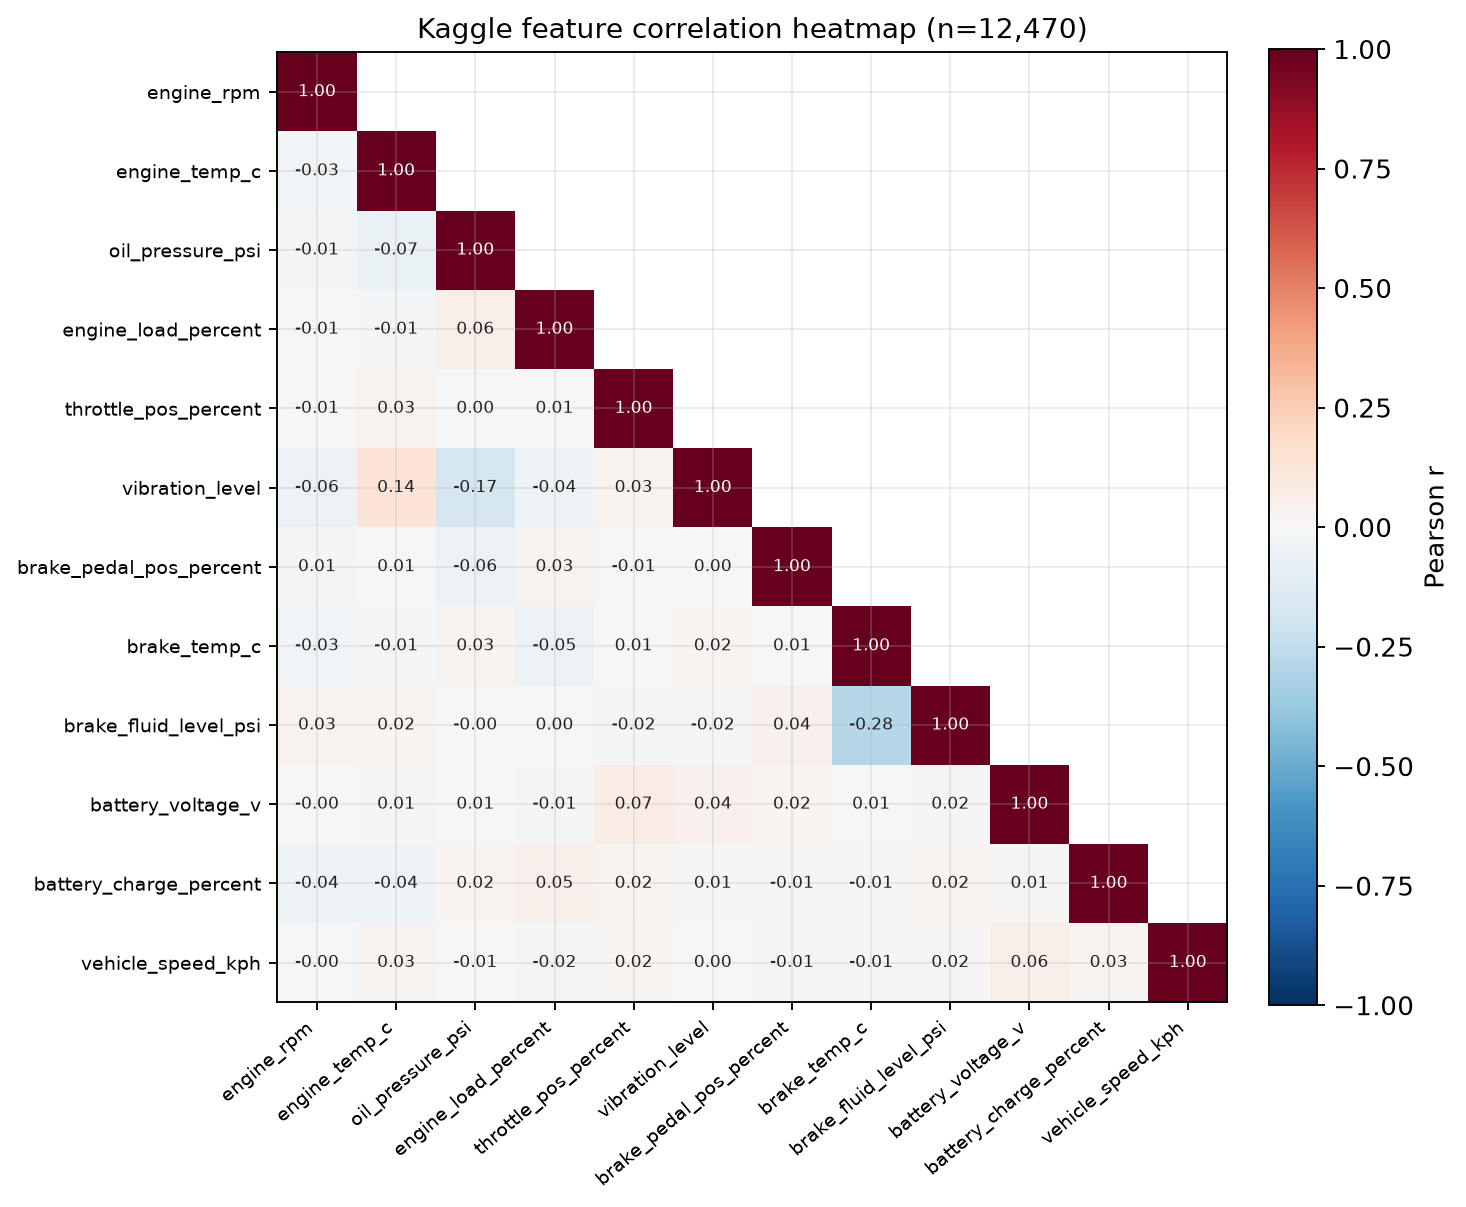

headline_comparison.png


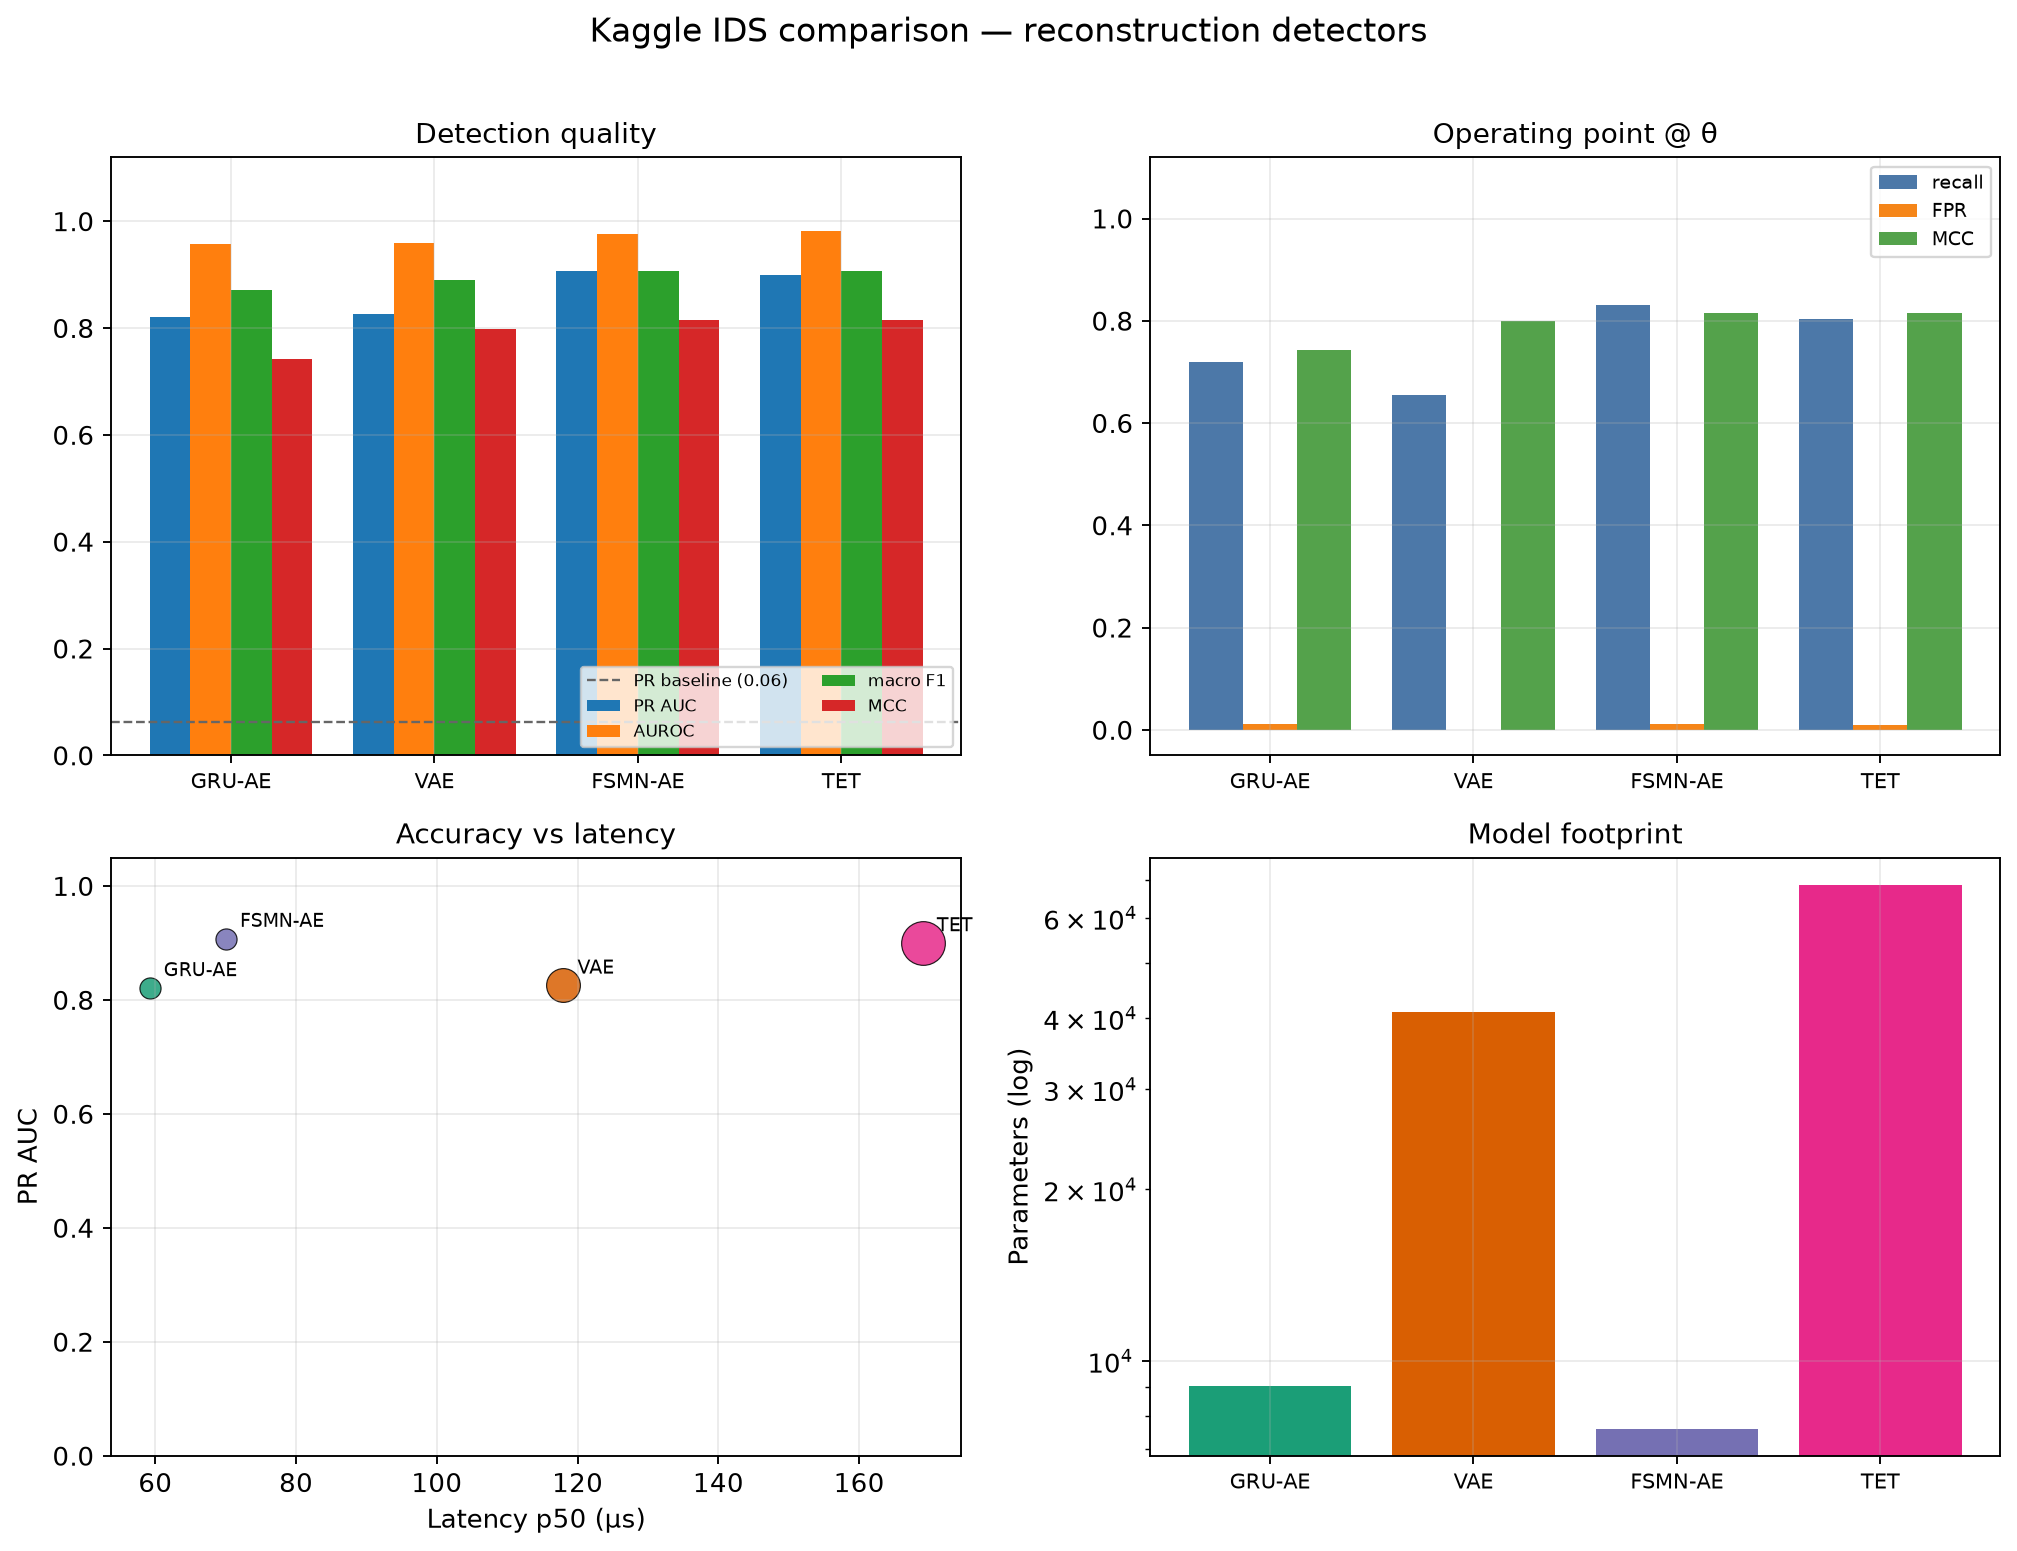

detection_quality.png


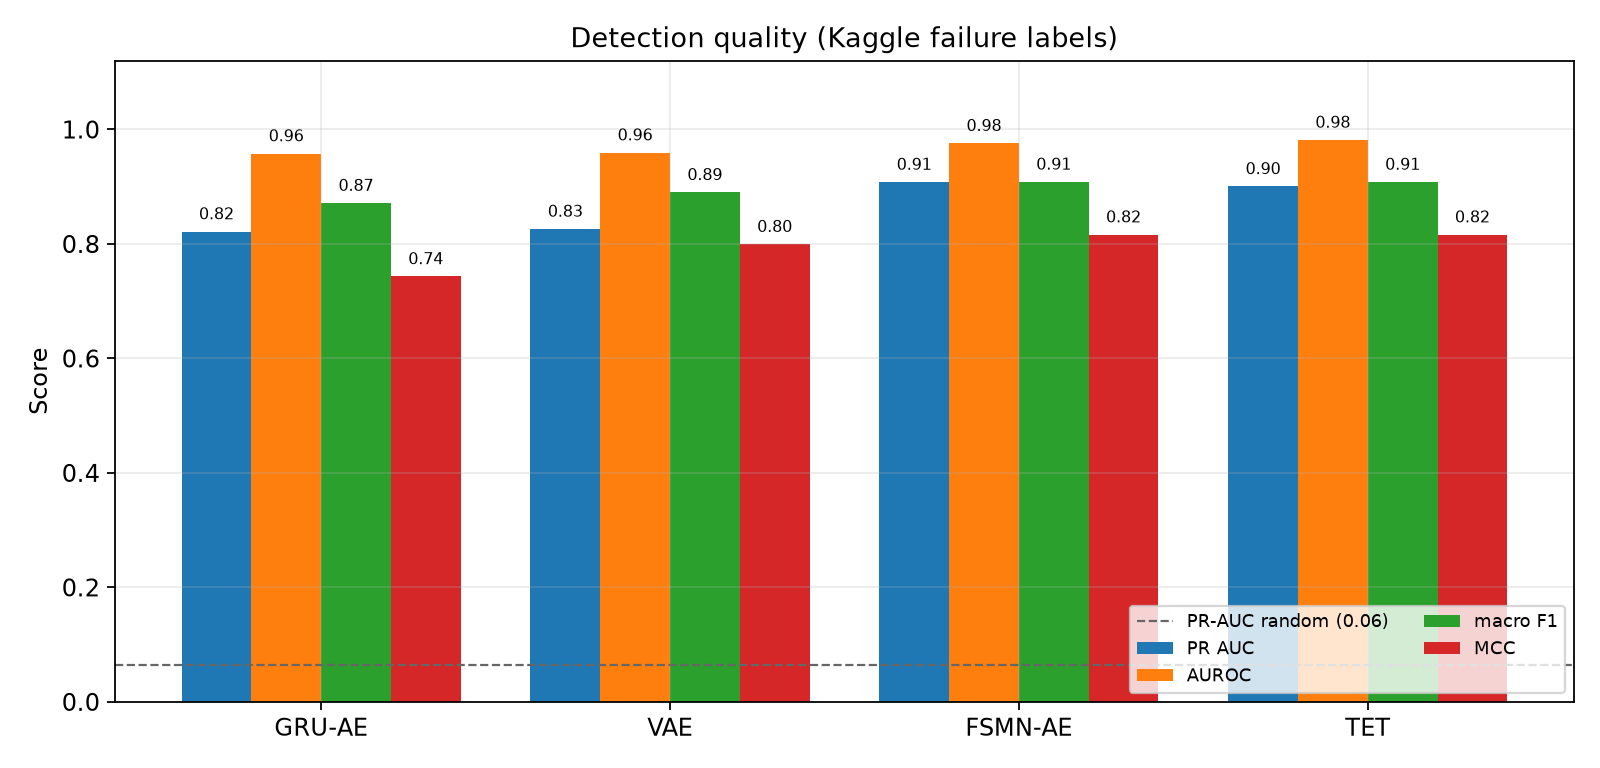

operating_point.png


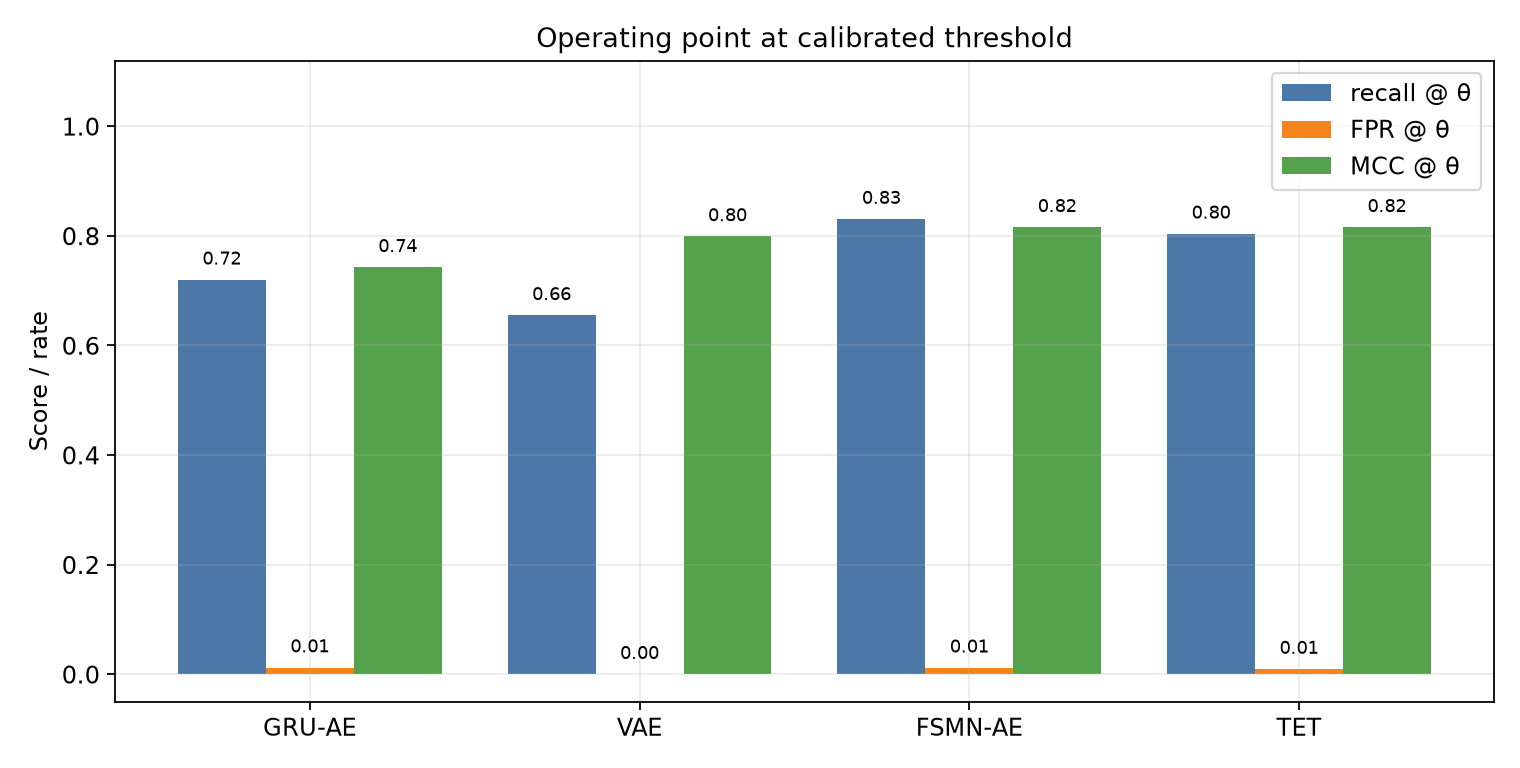

accuracy_vs_cost.png


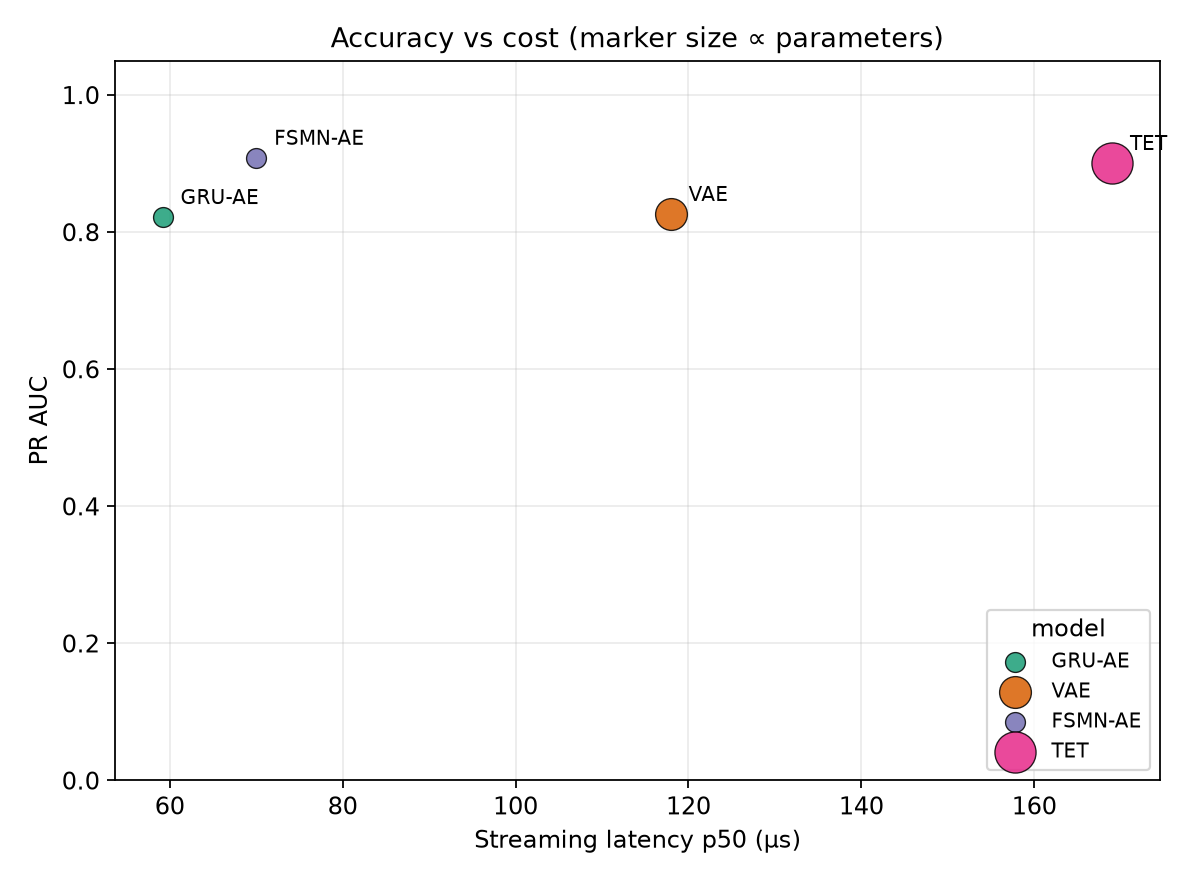

footprint.png


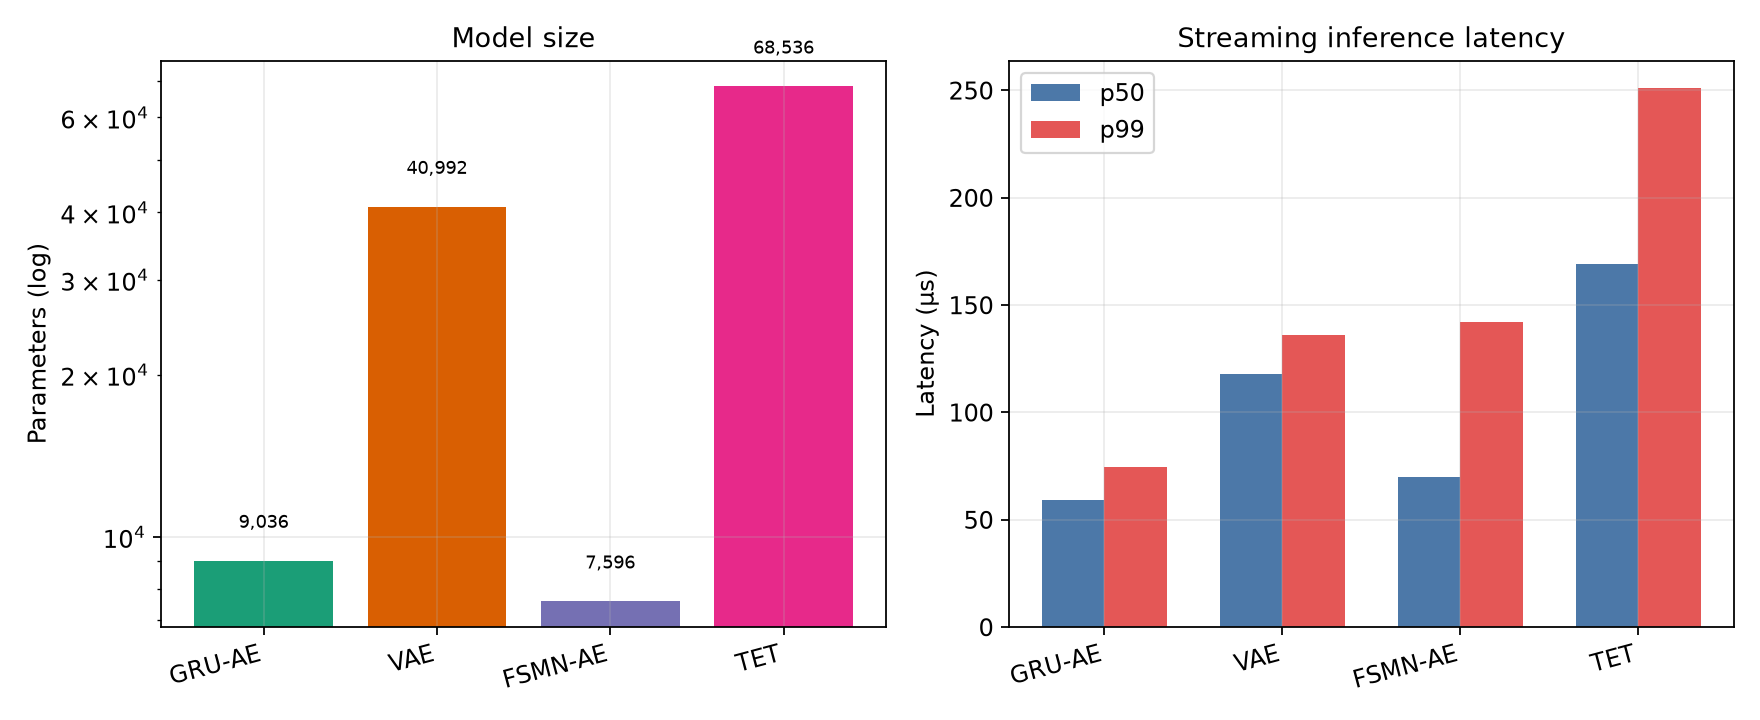

In [3]:
import pandas as pd
from IPython.display import Image, display

metrics = pd.read_csv(OUT / "metrics.csv")
display(metrics.round(3))

for name in [
    "feature_heatmap.png",
    "headline_comparison.png",
    "detection_quality.png",
    "operating_point.png",
    "accuracy_vs_cost.png",
    "footprint.png",
]:
    path = OUT / name
    print(path.name)
    display(Image(filename=str(path)))
